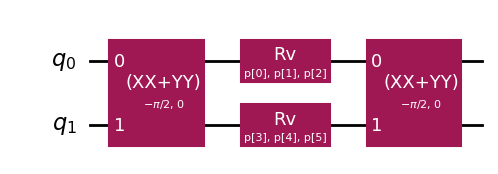

In [22]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RVGate, iSwapGate, CXGate
from qiskit.quantum_info import Operator
from qiskit.quantum_info.random import random_unitary
from scipy.optimize import minimize
from tqdm import tqdm

from gulps.core.invariants import GateInvariants
from gulps.viz.invariant_viz import scatter_plot

sentence_length = 2
random_restarts = 1
basis_gate = iSwapGate().power(1 / 2)


def ansatz():
    num_params = 6 * sentence_length
    p = ParameterVector("p", num_params)
    qc = QuantumCircuit(2)
    qc.append(basis_gate, [0, 1])
    # qc.append(GateInvariants.from_weyl((0.5, 0.5, 0.5)).gate, [0, 1])
    i = 0
    qc.append(RVGate(p[0 + 6 * i], p[1 + 6 * i], p[2 + 6 * i]), [0])
    qc.append(RVGate(p[3 + 6 * i], p[4 + 6 * i], p[5 + 6 * i]), [1])
    qc.append(basis_gate, [0, 1])
    # qc.append(GateInvariants.from_weyl((0.5, 0.25, 0.25)).gate.inverse(), [0, 1])
    return qc, num_params


def bind_ansatz(p):
    bound_qc = ansatz_qc.assign_parameters(
        {param: val for param, val in zip(ansatz_qc.parameters, p)}
    )
    return GateInvariants.from_unitary(Operator(bound_qc))


successes = []

ansatz_qc, num_params = ansatz()
ansatz_qc.draw("mpl")

In [23]:
def bind_ansatz(p):
    bound_qc = ansatz_qc.assign_parameters(
        {param: val for param, val in zip(ansatz_qc.parameters, p)}
    )
    return GateInvariants.from_unitary(Operator(bound_qc))


# successes = []
# failures = []
# # target_invariant = (GateInvariants.from_unitary(random_unitary(4)) for _ in range(N))
# # target_invariant = [GateInvariants.from_weyl((0.5, 0.5, 0.5))]
# target_invariant = [GateInvariants.from_weyl((0.5, 0.25, 0.25))]
# N = 1
# for target_gate in tqdm(
#     target_invariant,
#     total=N,
#     desc="Naive synthesis",
# ):

#     def makhlin_objective(p):
#         U = bind_ansatz(p)
#         return np.linalg.norm(np.array(U.makhlin) - np.array(target_gate.makhlin)) ** 2

#     succeeded = False
#     for _ in range(random_restarts):
#         attempt = minimize(
#             makhlin_objective,
#             x0=np.pi * np.random.rand(num_params) - np.pi / 2,
#             method="Nelder-Mead",
#         )
#         if attempt.success and attempt.fun < 1e-4:
#             successes.append(target_gate)
#             succeeded = True
#             break
#     if not succeeded:
#         failures.append(target_gate)

# print(f"Converged: {len(successes)}/{N}")
# if successes:
#     fig, ax = scatter_plot(successes, color="blue", label="success")
# if failures:
#     fig, ax = scatter_plot(failures, ax=ax, color="red", label="fail")
# ax.legend()

  0%|          | 0/2048 [00:00<?, ?it/s]

100%|██████████| 2048/2048 [00:01<00:00, 1875.04it/s]


(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

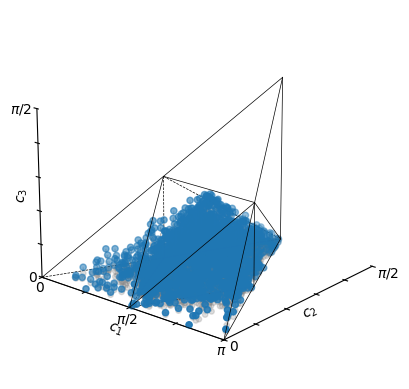

In [24]:
random_inv_list = []
for _ in tqdm(range(2048)):
    p = 2 * np.pi * np.random.rand(num_params) - np.pi / 2
    random_inv_list.append(bind_ansatz(p))
scatter_plot(random_inv_list)

In [25]:
from qiskit.synthesis.two_qubit import TwoQubitBasisDecomposer

basis_gate = iSwapGate().power(1 / 2)
decomposer = TwoQubitBasisDecomposer(basis_gate)
decomposer.num_basis_gates(random_unitary(4))

/tmp/ipykernel_1782283/4187713883.py:4: UserWarning: Only know how to decompose properly for a supercontrolled basis gate.
  decomposer = TwoQubitBasisDecomposer(basis_gate)


3